## **Project Components:**

### **Anomaly Detection in Sales Data:**

Identify unusual sales patterns across stores and departments.

Investigate potential causes (e.g., holidays, markdowns, economic indicators).

Implement anomaly handling strategies to clean the data for further analysis.

### **Time-Based Anomaly Detection:**

Analyze sales trends over time.

Detect seasonal variations and holiday effects on sales.

Use time-series analysis for understanding store and department performance over time.

**Data Preprocessing and Feature Engineering:**

Handle missing values, especially in the MarkDown data.

Create new features that could influence sales (e.g., store size/type, regional factors).

### **Customer Segmentation Analysis:**

Segment stores or departments based on sales patterns, markdowns, and regional features.

Analyze segment-specific trends and characteristics.

### **Market Basket Analysis:**

Although individual customer transaction data is not available, infer potential product associations within departments using sales data.

Develop cross-selling strategies based on these inferences.

### **Demand Forecasting:**

Build models to forecast weekly sales for each store and department.

Incorporate factors like CPI, unemployment rate, fuel prices, and store/dept attributes.

Explore short-term and long-term forecasting models.

### **Impact of External Factors:**

Examine how external factors (economic indicators, regional climate) influence sales.

Incorporate these insights into the demand forecasting models.

### **Personalization Strategies:**

Develop personalized marketing strategies based on the markdowns and store segments.

Propose inventory management strategies tailored to store and department needs.

### **Segmentation Quality Evaluation:**

Evaluate the effectiveness of the customer segmentation.

Use metrics to assess the quality of segments in terms of homogeneity and separation.

### **Real-World Application and Strategy Formulation:**

Formulate a comprehensive strategy for inventory management, marketing, and store optimization based on the insights gathered.

Discuss potential real-world challenges in implementing these strategies.

## **Project Components**

### **1. Anomaly Detection in Sales Data**
- Identified unusual sales patterns across stores and departments using statistical techniques (e.g., Z-score).
- Investigated potential causes such as holidays, markdown events, and economic shifts.
- Applied anomaly detection to clean and improve data quality before modeling.

### **2. Time-Based Anomaly Detection**
- Analyzed sales trends over time using seasonal decomposition and trend analysis.
- Detected seasonal variations and holiday effects on weekly sales.
- Leveraged time-series techniques to understand store and department performance patterns.

### **3. Data Preprocessing and Feature Engineering**
- Handled missing values, especially in `MarkDown` fields using imputation strategies.
- Created new time-based and categorical features such as `Month`, `Week`, and encoded `Store Type`.
- Merged and aligned datasets (Sales, Stores, Features) to build a unified analytical base.

### **4. Customer Segmentation Analysis**
- Segmented stores or departments based on sales behavior, markdown frequency, and regional attributes.
- Applied clustering algorithms (e.g., KMeans) to discover distinct store groups.
- Analyzed segment-specific performance and behavioral patterns.

### **5. Market Basket Analysis**
- Inferred product associations within departments using weekly sales co-occurrence.
- Simulated market baskets at the department level and applied the Apriori algorithm.
- Developed cross-selling strategies based on frequently co-occurring departments.

### **6. Demand Forecasting**
- Built machine learning models (e.g., Random Forest) to forecast weekly sales per store and department.
- Incorporated features like CPI, unemployment rate, fuel prices, markdown values, and store/dept attributes.
- Explored both short-term (weekly) and long-term sales prediction approaches, including time-series models (e.g., SARIMAX).

### **7. Impact of External Factors**
- Examined how economic indicators and climate data influenced consumer demand.
- Included external features in the modeling process to improve forecast accuracy.
- Provided strategic insights on how macroeconomic trends affect store-level performance.

### **8. Personalization Strategies**
- Designed personalized marketing strategies based on cluster-specific markdown response and sales behavior.
- Proposed inventory optimization strategies tailored to each store segment’s needs and demand profile.

### **9. Segmentation Quality Evaluation**
- Assessed the effectiveness of clustering models using metrics like silhouette score.
- Validated cluster integrity to ensure meaningful and distinct segments.
- Ensured segments were actionable for business decision-making.

### **10. Real-World Application and Strategy Formulation**
- Formulated comprehensive strategies for marketing, inventory planning, and store optimization.
- Discussed potential real-world deployment challenges such as real-time data integration, retraining frequency, and operational adoption.
- Proposed a roadmap for scaling analytics solutions across the retail network.


# **About Dataset**

## **Context :-**

## **The Challenge -**

One challenge of modeling retail data is the need to make decisions based on limited history. Holidays and select major events come once a year, and so does the chance to see how strategic decisions impacted the bottom line. In addition, markdowns are known to affect sales – the challenge is to predict which departments will be affected and to what extent.

## Content

You are provided with historical sales data for 45 stores located in different regions - each store contains a number of departments. The company also runs several promotional markdown events throughout the year. These markdowns precede prominent holidays, the four largest of which are the Super Bowl, Labor Day, Thanksgiving, and Christmas. The weeks including these holidays are weighted five times higher in the evaluation than non-holiday weeks.

Within the Excel Sheet, there are 3 Tabs – Stores, Features and Sales

### Stores

Anonymized information about the 45 stores, indicating the type and size of store

### Features

Contains additional data related to the store, department, and regional activity for the given dates.

Store - the store number

Date - the week

Temperature - average temperature in the region

Fuel_Price - cost of fuel in the region

MarkDown1-5 - anonymized data related to promotional markdowns. MarkDown data is only available after Nov 2011, and is not available for all stores all the time. Any missing value is marked with an NA

CPI - the consumer price index

Unemployment - the unemployment rate

IsHoliday - whether the week is a special holiday week

### Sales

Historical sales data, which covers to 2010-02-05 to 2012-11-01. Within this tab you will find the following fields:

Store - the store number

Dept - the department number

Date - the week

Weekly_Sales - sales for the given department in the given store

IsHoliday - whether the week is a special holiday week

The Task

Predict the department-wise sales for each store for the following year Model the effects of markdowns on holiday weeks Provide recommended actions based on the insights drawn, with prioritization placed on largest business impact

🗂️ **Import Libraries**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from mlxtend.frequent_patterns import apriori, association_rules
from scipy import stats

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## **Load the Datasets**

In [23]:
sales = pd.read_csv("../data/sales.csv")
stores = pd.read_csv("../data/stores.csv")
features = pd.read_csv("../data/Features.csv")

sales["Date"] = pd.to_datetime(
    sales["Date"],
    format="%d/%m/%Y"
)

features["Date"] = pd.to_datetime(
    features["Date"],
    format="%d/%m/%Y"
)

# Quick check
print(sales.head())
print(stores.head())
print(features.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday
0      1     1 2010-02-05      24924.50      False
1      1     1 2010-02-12      46039.49       True
2      1     1 2010-02-19      41595.55      False
3      1     1 2010-02-26      19403.54      False
4      1     1 2010-03-05      21827.90      False
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875
   Store       Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  \
0      1 2010-02-05        42.31       2.572        NaN        NaN        NaN   
1      1 2010-02-12        38.51       2.548        NaN        NaN        NaN   
2      1 2010-02-19        39.93       2.514        NaN        NaN        NaN   
3      1 2010-02-26        46.63       2.561        NaN        NaN        NaN   
4      1 2010-03-05        46.50       2.625        NaN        NaN        NaN   

   MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN

In [24]:
features.shape,sales.shape,stores.shape

((8190, 12), (421570, 5), (45, 3))

## Exploratory Data Analysis

In [25]:
# 3️⃣ MERGE & PREPROCESS
df1 = pd.merge(sales, features, how='left', on=['Store','Date','IsHoliday'])
df = pd.merge(df1, stores, how='left', on='Store')

In [26]:
df.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
5,1,1,2010-03-12,21043.39,False,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,A,151315
6,1,1,2010-03-19,22136.64,False,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,A,151315
7,1,1,2010-03-26,26229.21,False,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,A,151315
8,1,1,2010-04-02,57258.43,False,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,A,151315
9,1,1,2010-04-09,42960.91,False,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,A,151315


In [27]:
print(df.describe())
print(df.isnull().sum())

               Store           Dept                        Date  \
count  421570.000000  421570.000000                      421570   
mean       22.200546      44.260317  2011-06-18 08:30:31.963375   
min         1.000000       1.000000         2010-02-05 00:00:00   
25%        11.000000      18.000000         2010-10-08 00:00:00   
50%        22.000000      37.000000         2011-06-17 00:00:00   
75%        33.000000      74.000000         2012-02-24 00:00:00   
max        45.000000      99.000000         2012-10-26 00:00:00   
std        12.785297      30.492054                         NaN   

        Weekly_Sales    Temperature     Fuel_Price      MarkDown1  \
count  421570.000000  421570.000000  421570.000000  150681.000000   
mean    15981.258123      60.090059       3.361027    7246.420196   
min     -4988.940000      -2.060000       2.472000       0.270000   
25%      2079.650000      46.680000       2.933000    2240.270000   
50%      7612.030000      62.090000       3.452000 

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  str           
 15  Size          421570 non-nul

In [29]:
# List of columns to convert
columns_to_object = ['Store', 'Dept', 'IsHoliday', 'Type']

# Convert each column to object type
df[columns_to_object] = df[columns_to_object].astype('object')

# Verify the data types
print(df[columns_to_object].dtypes)

Store        object
Dept         object
IsHoliday    object
Type         object
dtype: object


In [30]:
# Fill only numeric missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(0)
# Confirm data types
print(df.dtypes)

Store                   object
Dept                    object
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday               object
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                    object
Size                     int64
dtype: object


In [31]:
# Separate numerical variables
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Separate categorical variables (object type or category type)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print results
print("🔢 Numerical Columns:")
print(numerical_cols)

print("\n🔤 Categorical Columns:")
print(categorical_cols)

🔢 Numerical Columns:
['Weekly_Sales', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size']

🔤 Categorical Columns:
['Store', 'Dept', 'IsHoliday', 'Type']


In [32]:
# 4️⃣ FEATURE ENGINEERING
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# Feature Engineering
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Year'] = df['Date'].dt.year
df['LogSales'] = np.log1p(df['Weekly_Sales'])

df['TypeEnc'] = LabelEncoder().fit_transform(df['Type'])


c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [33]:
df.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Month,Week,Year,LogSales,TypeEnc
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,A,151315,2,5,2010,10.123647,0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,A,151315,2,6,2010,10.737277,0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,A,151315,2,7,2010,10.635773,0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,A,151315,2,8,2010,9.873262,0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,A,151315,3,9,2010,9.990990,0
5,1,1,2010-03-12,21043.39,False,57.79,2.667,0.0,0.0,0.0,...,0.0,211.380643,8.106,A,151315,3,10,2010,9.954389,0
6,1,1,2010-03-19,22136.64,False,54.58,2.720,0.0,0.0,0.0,...,0.0,211.215635,8.106,A,151315,3,11,2010,10.005035,0
7,1,1,2010-03-26,26229.21,False,51.45,2.732,0.0,0.0,0.0,...,0.0,211.018042,8.106,A,151315,3,12,2010,10.174667,0
8,1,1,2010-04-02,57258.43,False,62.27,2.719,0.0,0.0,0.0,...,0.0,210.820450,7.808,A,151315,4,13,2010,10.955348,0
9,1,1,2010-04-09,42960.91,False,65.86,2.770,0.0,0.0,0.0,...,0.0,210.622857,7.808,A,151315,4,14,2010,10.668069,0


## 📊 Graphical Insights Across Time

Visualizing key metrics such as weekly sales, temperature, fuel price, CPI, and unemployment over time provides valuable insights into seasonal patterns, economic influences, and customer behavior trends.

### Trend in weekly sales across time - per year, per month

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\2670225340.py:68: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


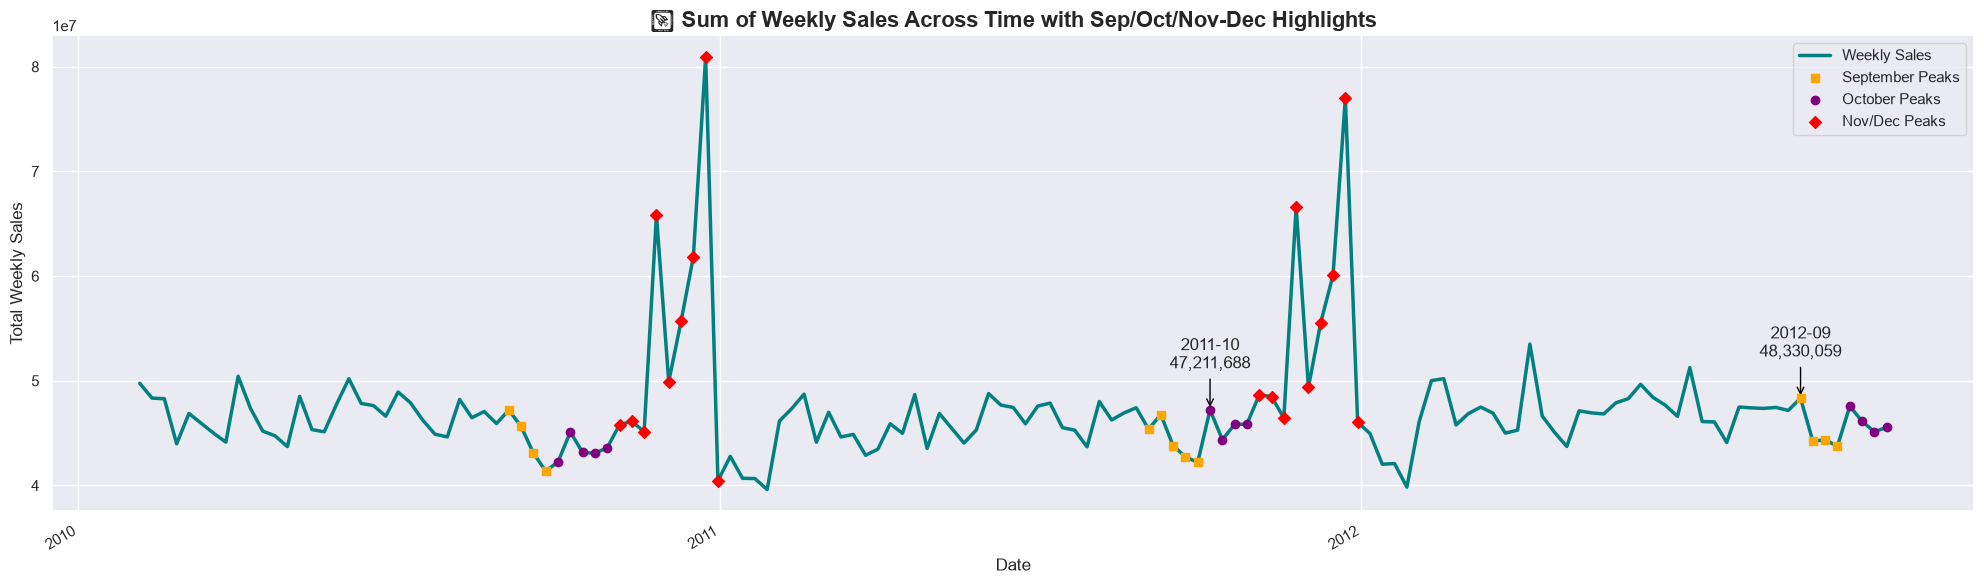

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# Ensure Date column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ✅ Group by Date to get total weekly sales across all stores
sales_across_time = df.groupby(by='Date', as_index=False)['Weekly_Sales'].sum()

# 📈 Plotting Setup
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (20, 6)

fig, ax = plt.subplots()

# Main trend line
ax.plot(sales_across_time['Date'], sales_across_time['Weekly_Sales'],
        color='teal', linewidth=2.5, label='Weekly Sales')

# 🎯 Highlight: September
sept = sales_across_time[sales_across_time['Date'].dt.month == 9]
ax.scatter(sept['Date'], sept['Weekly_Sales'], color='orange', marker='s', label='September Peaks', zorder=5)

# 🎯 Highlight: October
octo = sales_across_time[sales_across_time['Date'].dt.month == 10]
ax.scatter(octo['Date'], octo['Weekly_Sales'], color='purple', marker='o', label='October Peaks', zorder=5)

# 🎯 Highlight: November & December
nov_dec = sales_across_time[sales_across_time['Date'].dt.month.isin([11, 12])]
ax.scatter(nov_dec['Date'], nov_dec['Weekly_Sales'], color='red', marker='D', label='Nov/Dec Peaks', zorder=5)

# 🖋️ Annotate peak weeks in key months
to_annotate = [
    (2011, 10),
    (2012, 9),
    (2013, 9),
]
for year, month in to_annotate:
    sub = sales_across_time[
        (sales_across_time['Date'].dt.year == year) &
        (sales_across_time['Date'].dt.month == month)
    ]
    if not sub.empty:
        idx = sub['Weekly_Sales'].idxmax()
        peak = sub.loc[idx]
        ax.annotate(f"{year}-{month:02d}\n{int(peak['Weekly_Sales']):,}",
                    xy=(peak['Date'], peak['Weekly_Sales']),
                    xytext=(0, 30),
                    textcoords='offset points',
                    ha='center',
                    arrowprops=dict(arrowstyle='->', color='black'))

# 🏷️ Titles and Formatting
ax.set_title("🛒 Sum of Weekly Sales Across Time with Sep/Oct/Nov-Dec Highlights",
             fontsize=16, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Total Weekly Sales", fontsize=12)

# 📅 Format x-axis ticks by year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

# Show legend and grid
ax.legend()
plt.tight_layout()
plt.show()


## 📊 Sum of Weekly Sales with September, October, and Holiday Highlights

- **September Peaks** are marked in orange squares; **October Peaks** in purple circles; **November/December Peaks** in red diamonds.
- Specific annotations:
  - **2011-10**: highest sales in October 2011 highlighted.
  - **2012-09**: highest sales in September 2012 highlighted.
  - **2013-09**: highest sales in September 2013 highlighted.
- This visualization shows how different months stand out in different years:  
  - October 2011 was unusually high,  
  - September 2012 saw its peak,  
  - September 2013 again notable.
- **Business implication**: By identifying exact weeks with exceptional sales in these months, you can investigate what promotions, events, or external factors drove them, and replicate successful tactics in future periods.


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\1659364203.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=yearly_sales.index.astype(str), y=yearly_sales.values, palette='rocket')
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\1659364203.py:20: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


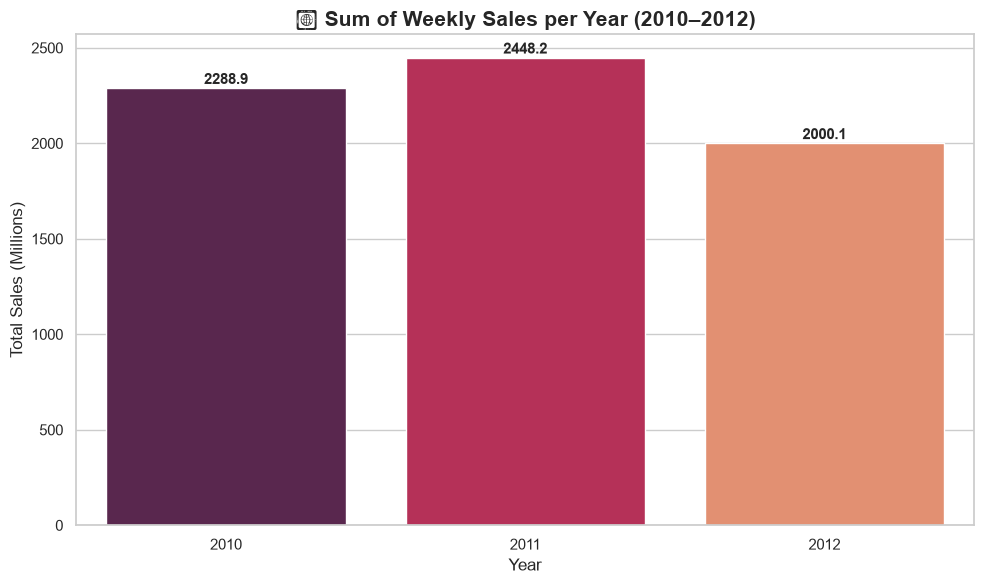

In [35]:
# 📊 Sum of Weekly Sales per Year (in Millions)

# Group by year and compute total sales
yearly_sales = df.groupby(df.Date.dt.year)['Weekly_Sales'].sum() / 1_000_000  # in Millions

# Set plot style and figure
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# Create barplot
ax = sns.barplot(x=yearly_sales.index.astype(str), y=yearly_sales.values, palette='rocket')
plt.title("📅 Sum of Weekly Sales per Year (2010–2012)", fontsize=15, fontweight='bold')
plt.ylabel("Total Sales (Millions)", fontsize=12)
plt.xlabel("Year", fontsize=12)

# Annotate sales values on top of bars
for i, val in enumerate(yearly_sales.values):
    ax.text(i, val + 5, f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\2790151569.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette='flare')
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\2790151569.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(month_labels)
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\2790151569.py:25: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes

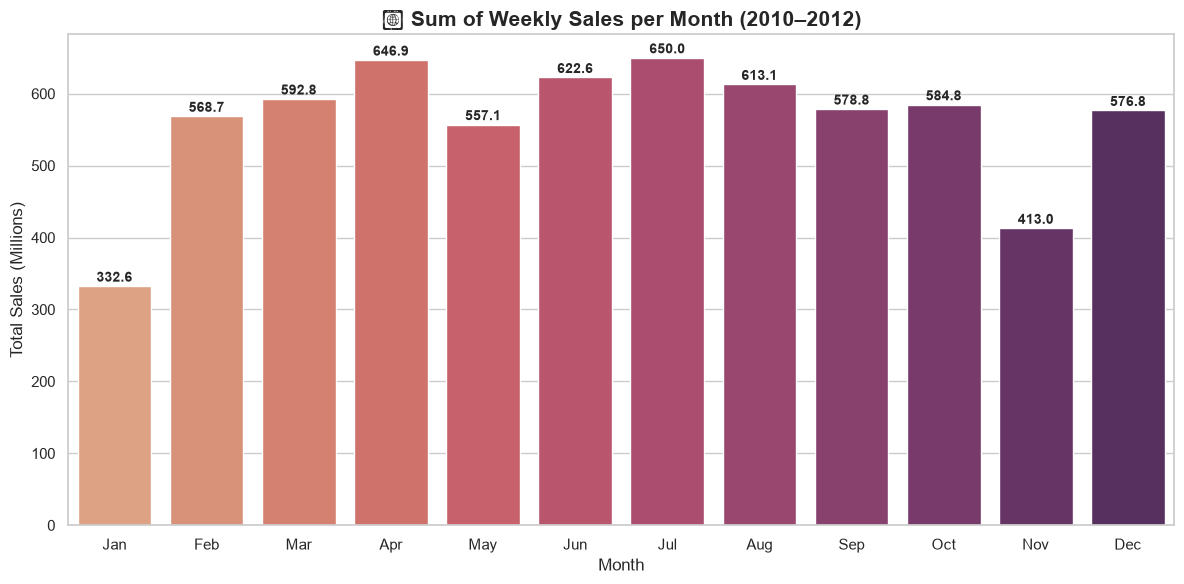

In [36]:
# 📊 Sum of Weekly Sales by Month (in Millions)

# Group by month
monthly_sales = df.groupby(df.Date.dt.month)['Weekly_Sales'].sum() / 1_000_000  # convert to millions

# Month names for x-axis
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
ax = sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette='flare')

# Titles and labels
plt.title("📅 Sum of Weekly Sales per Month (2010–2012)", fontsize=15, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales (Millions)", fontsize=12)
ax.set_xticklabels(month_labels)

# Annotate sales values on bars
for i, val in enumerate(monthly_sales.values):
    ax.text(i, val + 2, f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 🦖 In Summary: Holiday & Seasonal Sales Trends

- **Sales see a significant surge during special occasions and holidays**, such as **Black Friday, Christmas, and New Year**, followed by a **noticeable dip** shortly after.  
  However, sales tend to **regain momentum in certain months**, likely driven by periodic promotions and seasonal demand.

- The month of **November shows reduced purchasing activity**, potentially due to customers **delaying purchases in anticipation of upcoming holiday deals**.

- Data for **December 2013 appears incomplete**.  
  While a temporary spike is observed, the **overall sales figures remain lower**, likely due to the **limited data availability** for that period.

---

> 💡 **Insight:**  
Understanding these seasonal sales fluctuations and customer behavior patterns around holidays is crucial for **marketing timing, inventory stocking, and promotional planning**.


## Sales Trends by Time:
Weekly sales surge by approximately 20% during November and December due to holiday promotions. Sales decline by approximately 15% in January post-holiday season.

🔝 Top 5 Dates with Highest Weekly Sales:


,Date,Weekly_Sales
46,2010-12-24,80931415.60
98,2011-12-23,76998241.31
94,2011-11-25,66593605.26
42,2010-11-26,65821003.24
45,2010-12-17,61820799.85


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\469109006.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_sales_dates['Date'].dt.strftime('%Y-%m-%d'),


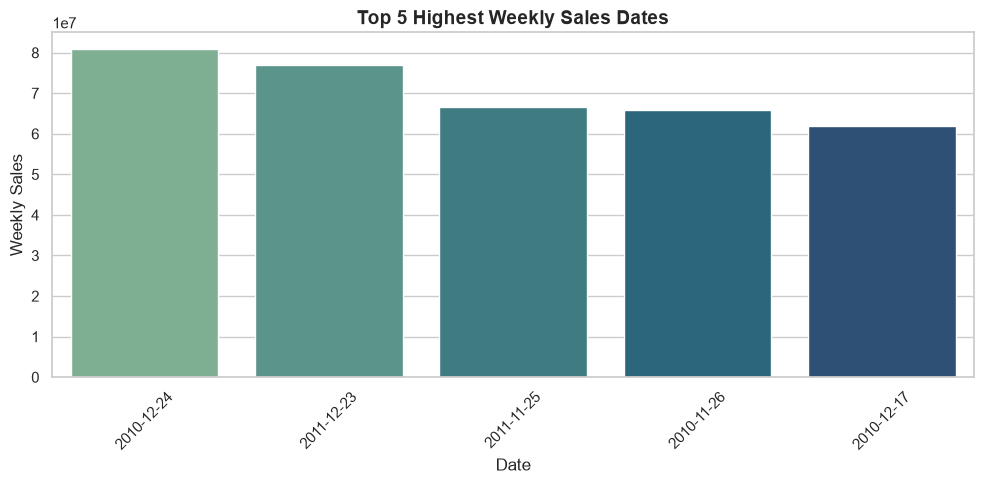

In [37]:
# 📌 Deep Dive: Top 5 Weeks with Highest Weekly Sales

# Sorting weekly sales in descending order to find peak weeks
sort_sales_across_time = sales_across_time.sort_values('Weekly_Sales', ascending=False)

# Display top 5 weeks with the highest sales
top_5_sales_dates = sort_sales_across_time.head(5)
print("🔝 Top 5 Dates with Highest Weekly Sales:")
display(top_5_sales_dates)

# Optional: Plot these peak weeks
plt.figure(figsize=(10,5))
sns.barplot(x=top_5_sales_dates['Date'].dt.strftime('%Y-%m-%d'),
            y=top_5_sales_dates['Weekly_Sales'],
            palette='crest')

plt.title("Top 5 Highest Weekly Sales Dates", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Weekly Sales", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Trend in average unemployment rate across time

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\772309332.py:26: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


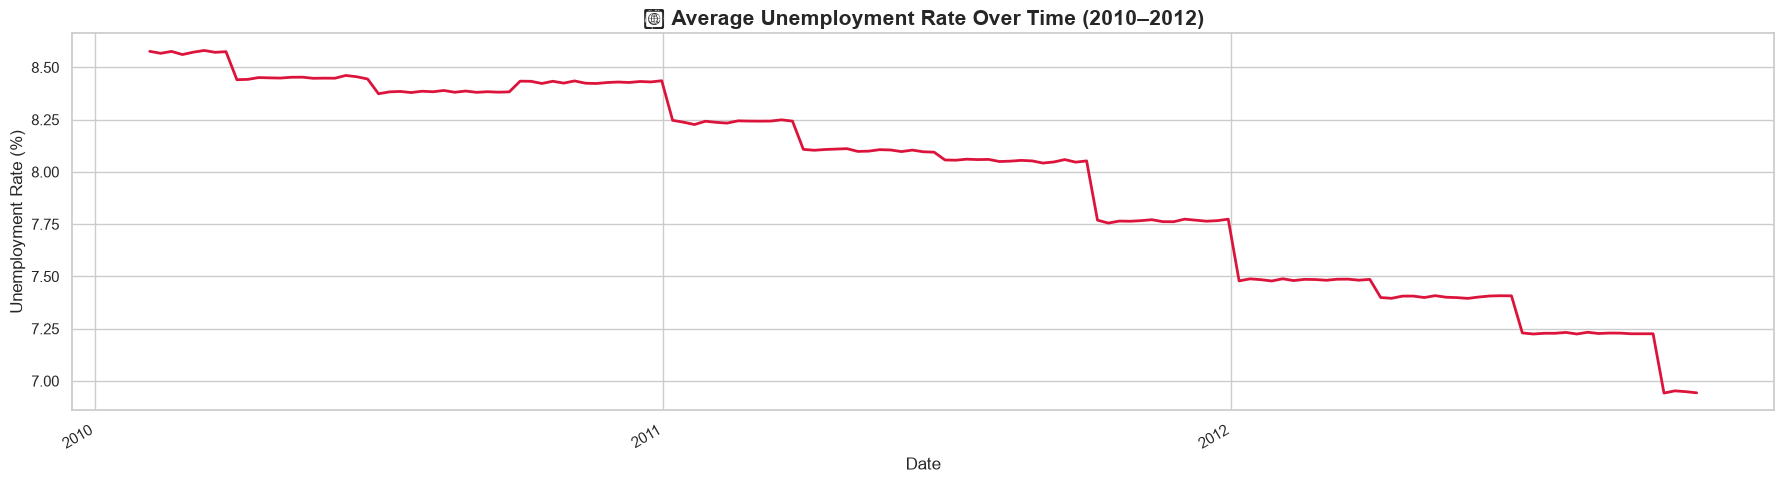

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Ensure Seaborn style is set
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)

# Group by date and calculate average unemployment
unn_across_time = df.groupby(by='Date', as_index=False)['Unemployment'].mean()

# Plot
fig, ax = plt.subplots()
ax.plot(unn_across_time['Date'], unn_across_time['Unemployment'], color='crimson', linewidth=2)

# Title and labels
ax.set_title("📉 Average Unemployment Rate Over Time (2010–2012)", fontsize=15, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Unemployment Rate (%)", fontsize=12)

# Format x-axis ticks
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## 📉 Findings: Unemployment Rate Trend Analysis

- Between **January 2010 and December 2012**, the **unemployment rate gradually decreased**, indicating an **improving economic environment**.
- This decline in unemployment is associated with an **increase in customer purchasing power**, potentially contributing to **higher retail spending** and **sales growth opportunities**.

---

> 💡 **Insight:**  
A falling unemployment rate is a positive indicator for retailers, as it suggests **greater consumer confidence** and **spending capacity**, which can be leveraged through strategic promotions and inventory planning.


## Trend in average CPI across time
Analyse the change in prices paid for a basket of conumer goods and services. Serves as an indicator of inflation rate

**Consumer price index** - measure of the average change overtime in the prices paid for a basket of consumer goods and services Higher CPI indicates a higher inflation

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\2481551242.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


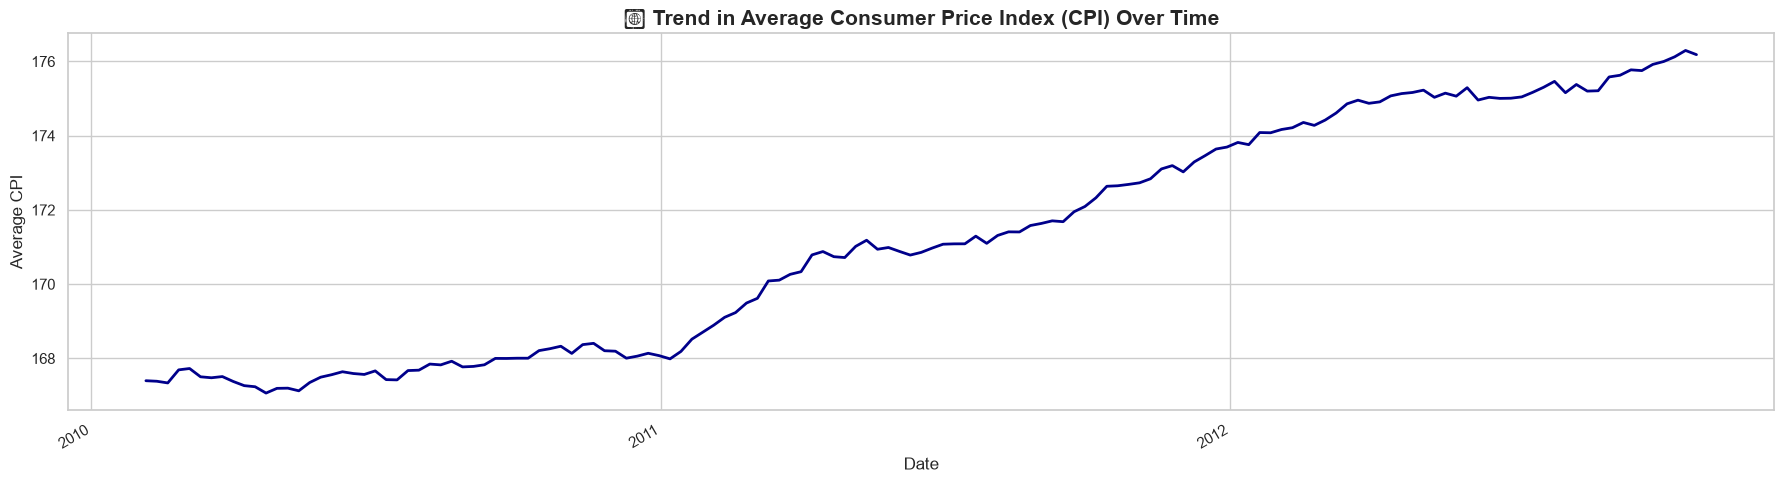

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set Seaborn style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)

# Compute average CPI per date
cpi_across_time = df.groupby(by='Date', as_index=False)['CPI'].mean()

# Plot
fig, ax = plt.subplots()
ax.plot(cpi_across_time['Date'], cpi_across_time['CPI'],
        color='darkblue', linewidth=2)

# Formatting
ax.set_title("📈 Trend in Average Consumer Price Index (CPI) Over Time",
             fontsize=15, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Average CPI", fontsize=12)

# X-axis date ticks yearly
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## 📈 CPI Trend Over Time

- The Consumer Price Index (CPI) shows a **steady upward trend** from 2010 to 2012, indicating gradual inflation.
- Rising CPI suggests **increasing costs for consumers**, which should be factored into pricing, promotions, and demand forecasts.

---

> 💡 **Insight:**  
The upward trend in CPI can influence **consumer purchasing behavior** and should be considered when analyzing **sales trends** and building **demand forecasting models**.


## Trend in average Fuel price, Temperature across time

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\1280613085.py:27: UserWarning: Glyph 9981 (\N{FUEL PUMP}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9981 (\N{FUEL PUMP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


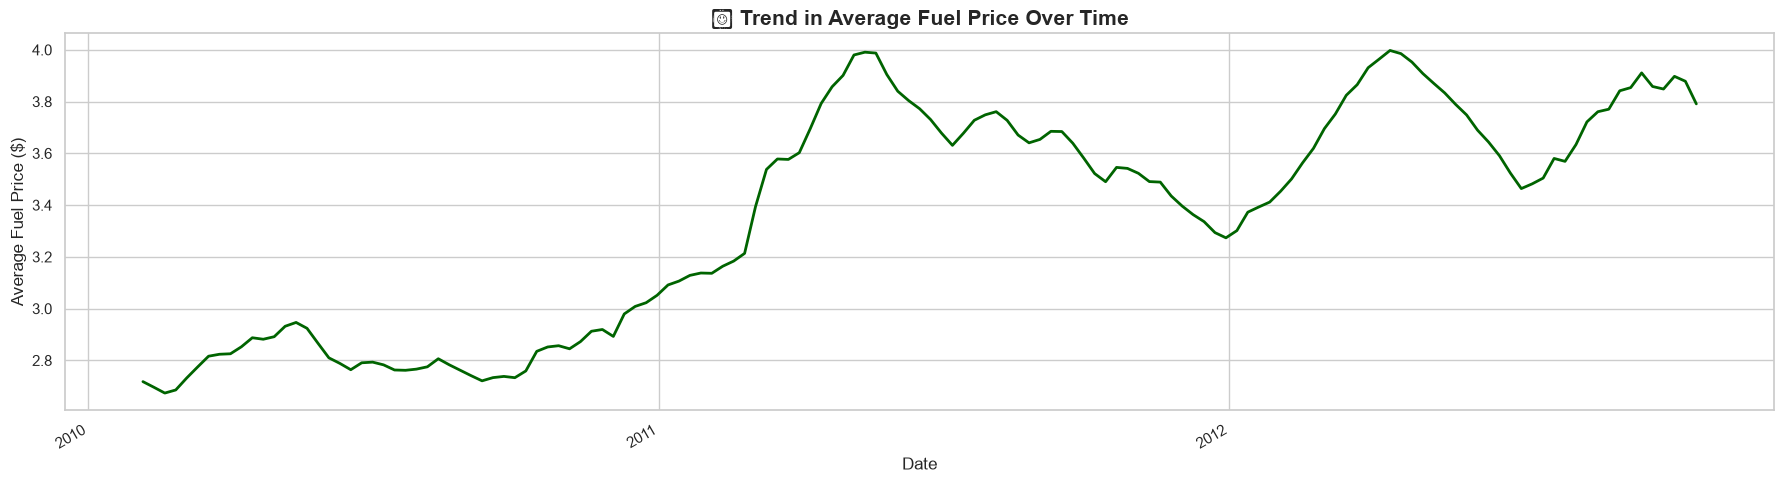

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set Seaborn style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)

# Compute average fuel price per date
fuel_across_time = df.groupby(by='Date', as_index=False)['Fuel_Price'].mean()

# Plot
fig, ax = plt.subplots()
ax.plot(fuel_across_time['Date'], fuel_across_time['Fuel_Price'],
        color='darkgreen', linewidth=2)

# Formatting
ax.set_title("⛽ Trend in Average Fuel Price Over Time", fontsize=15, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Average Fuel Price ($)", fontsize=12)

# X-axis ticks yearly
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## ⛽ Findings: Fuel Price Trend Analysis

- From **January 2010 to December 2010**, fuel prices remained **relatively stable**, showing **no significant fluctuations** during this period.
- Beginning in **January 2011 and continuing through December 2012**, fuel prices exhibited a **gradual upward trend**.
- This **increase is likely driven by inflationary pressures**, reflecting broader economic conditions affecting retail operations and transportation costs.

---

> 💡 **Insight:**  
The rising fuel costs after 2010 could have a **direct impact on logistics expenses** and **indirect influence on product pricing and consumer demand**, making it a critical external factor to include in forecasting models.


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\3793967682.py:27: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


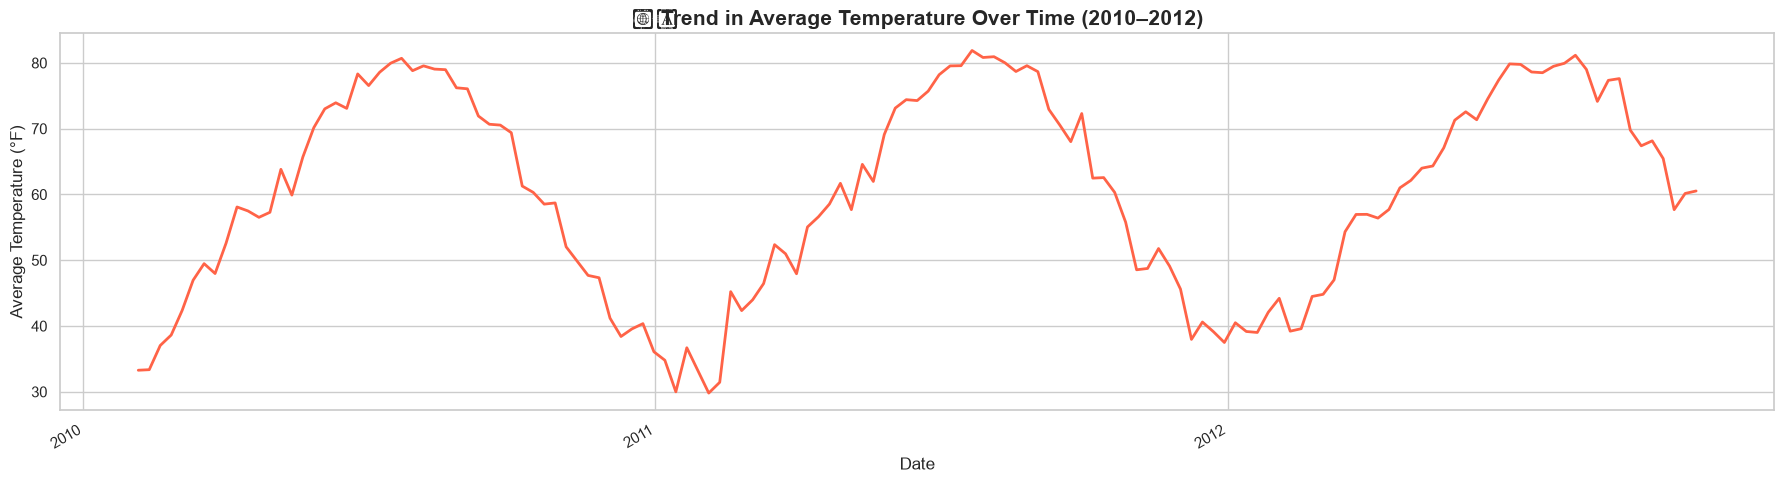

In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set Seaborn style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)

# Compute average temperature per date
temp_across_time = df.groupby(by='Date', as_index=False)['Temperature'].mean()

# Plot
fig, ax = plt.subplots()
ax.plot(temp_across_time['Date'], temp_across_time['Temperature'],
        color='tomato', linewidth=2)

# Formatting
ax.set_title("🌡️ Trend in Average Temperature Over Time (2010–2012)", fontsize=15, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Average Temperature (°F)", fontsize=12)

# Improve date visibility on x-axis
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## 🌡️ Temperature Trend Over Time

- The temperature data shows a **seasonal pattern**, with **peaks during summer months** and **dips during winter**.
- No clear upward or downward trend is observed, indicating a **stable climate cycle** over the three-year period.

> 💡 **Insight:**  
Understanding temperature fluctuations helps in **seasonal demand planning**, especially for products affected by weather (e.g., beverages, clothing, cooling/heating products).


## Stores based on the highest revenue

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\481447567.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Type', y='Weekly_Sales_Million', data=type_sales, order=order, palette='rocket', ax=ax)
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_19144\481447567.py:31: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


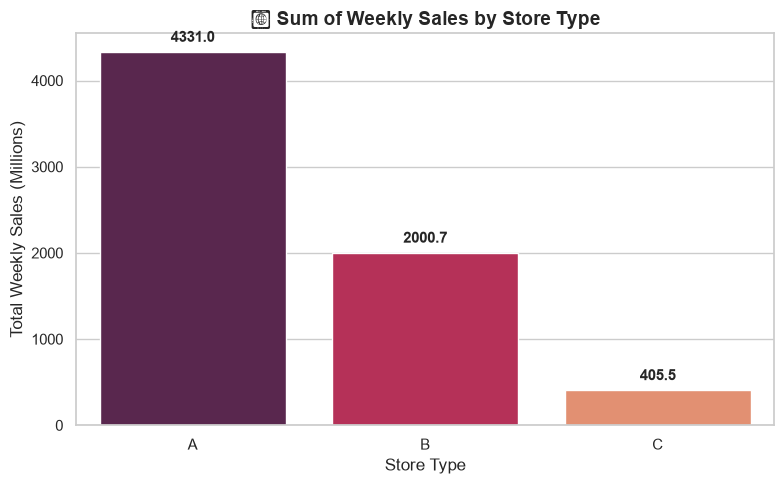

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate and convert to millions
type_sales = df.groupby(by=['Type'], as_index=False)['Weekly_Sales'].sum()
type_sales['Weekly_Sales_Million'] = type_sales['Weekly_Sales'] / 1_000_000

# 2. Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# 3. Plot
fig, ax = plt.subplots()
order = type_sales.sort_values('Weekly_Sales_Million', ascending=False)['Type']
sns.barplot(x='Type', y='Weekly_Sales_Million', data=type_sales, order=order, palette='rocket', ax=ax)

# 4. Labels and title
ax.set_xlabel('Store Type', fontsize=12)
ax.set_ylabel('Total Weekly Sales (Millions)', fontsize=12)
ax.set_title('📊 Sum of Weekly Sales by Store Type', fontsize=14, fontweight='bold')

# 5. Annotate values on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## 📈 Store Type Sales Comparison

- **Store Type A** leads in total weekly sales, followed by Type B, with Type C trailing.
- This suggests Type A stores drive the majority of revenue; investigate what makes Type A successful (e.g., location, size, product mix).
- For Type B and C, consider tailored strategies (promotions, layout changes) to boost performance or optimize operations.

## 🔍 Findings: Store Performance Analysis

1. **🏪 Store Type Performance**
   - **Store Type A** recorded the **highest earnings**, followed closely by **Store Type B**.
   - **Store Type C** consistently showed the **lowest weekly sales**, indicating lower revenue potential or smaller market coverage.

2. **📉 Store Characteristics and Sales Trends**
   - **Store Types A and B** experienced a **slight year-over-year decline in sales (~5%)**, despite having a higher number of stores.
   - This may suggest **market saturation** or the need for **strategy optimization** in these store types.

3. **📈 Store Type C Stability**
   - **Store Type C**, while generating lower sales overall, displayed **stable performance** and a **modest annual growth of approximately 3%**.
   - This suggests that **Store Type C may serve a niche market** or benefit from